In [ ]:
import pandas as pd

1. Load Dataset

In [ ]:
# Load Dataset
DATA_PATH = "data_ecommerce_customer_churn.csv"

df = pd.read_csv(DATA_PATH)

print("Shape dataset:", df.shape)
print(df.head())

Shape dataset: (3941, 11)
   Tenure  WarehouseToHome  NumberOfDeviceRegistered    PreferedOrderCat  \
0    15.0             29.0                         4  Laptop & Accessory   
1     7.0             25.0                         4              Mobile   
2    27.0             13.0                         3  Laptop & Accessory   
3    20.0             25.0                         4             Fashion   
4    30.0             15.0                         4              Others   

   SatisfactionScore MaritalStatus  NumberOfAddress  Complain  \
0                  3        Single                2         0   
1                  1       Married                2         0   
2                  1       Married                5         0   
3                  3      Divorced                7         0   
4                  4        Single                8         0   

   DaySinceLastOrder  CashbackAmount  Churn  
0                7.0          143.32      0  
1                7.0          129.

2. Data Cleaning

In [ ]:
# Standarisasi Nama Kolom
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

print("Columns:")
print (df.columns)

Columns:
Index(['tenure', 'warehousetohome', 'numberofdeviceregistered',
       'preferedordercat', 'satisfactionscore', 'maritalstatus',
       'numberofaddress', 'complain', 'daysincelastorder', 'cashbackamount',
       'churn'],
      dtype='object')


In [ ]:
# Cek Missing Value

# Sebelum dibersihkan
missing_before = df.isnull().sum()
print("Missing Value Sebelum:")
print(missing_before)

# Proses Pembersihan
df = df.dropna()

# Sesudah Pembersihan
missing_after = df.isnull().sum()
print("\nMissing Value Sesudah:")
print(missing_after)

Missing Value Sebelum:
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

Missing Value Sesudah:
Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64


In [ ]:
# Cek Data Duplikat

# Sebelum dibersihkan
duplicates_before = df.duplicated().sum()
print("Jumlah duplikat sebelum:", duplicates_before)

# Proses Pembersihan
df = df.drop_duplicates()

# Sesudah Pembersihan
duplicates_after = df.duplicated().sum()
print("Jumlah duplikat sesudah:", duplicates_after)

Jumlah duplikat sebelum: 571
Jumlah duplikat sesudah: 0


In [ ]:
# Cek Tipe Data
print("Tipe data:")
print(df.dtypes)

Tipe data:
tenure                      float64
warehousetohome             float64
numberofdeviceregistered      int64
preferedordercat             object
satisfactionscore             int64
maritalstatus                object
numberofaddress               int64
complain                      int64
daysincelastorder           float64
cashbackamount              float64
churn                         int64
dtype: object


In [ ]:
# Distribusi Target
print(df["churn"].value_counts())

churn
0    2383
1     411
Name: count, dtype: int64
churn
0    85.29%
1    14.71%
Name: proportion, dtype: object


In [ ]:
# Data Frame Bersih
print("Shape setelah cleaning:", df.shape)

df_clean = df.copy()
df_clean.head()

Shape setelah cleaning: (2794, 11)


,tenure,warehousetohome,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,daysincelastorder,cashbackamount,churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
5,7.0,16.0,4,Mobile Phone,2,Divorced,2,0,11.0,152.81,0


3. Data Transformasi

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df_clean["preferedordercat"] = encoder.fit_transform(df_clean["preferedordercat"])
df_clean["maritalstatus"] = encoder.fit_transform(df_clean["maritalstatus"])

df_clean.head()

,tenure,warehousetohome,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,daysincelastorder,cashbackamount,churn
0,15.0,29.0,4,2,3,2,2,0,7.0,143.32,0
1,7.0,25.0,4,3,1,1,2,0,7.0,129.29,0
2,27.0,13.0,3,2,1,1,5,0,7.0,168.54,0
4,30.0,15.0,4,5,4,2,8,0,8.0,322.17,0
5,7.0,16.0,4,4,2,0,2,0,11.0,152.81,0


In [ ]:
# Pisahkan feature dan target

X = df_clean.drop(columns=['churn'])
y = df_clean['churn']

print("Shape Feature:", X.shape)
print("Shape Target:", y.shape)

Shape Feature: (2794, 10)
Shape Target: (2794,)


In [ ]:
# Cek Data Setelah Transformasi

print(X.head())
print("\nTarget sample:")
print(y.head())

   tenure  warehousetohome  numberofdeviceregistered  preferedordercat  \
0    15.0             29.0                         4                 2   
1     7.0             25.0                         4                 3   
2    27.0             13.0                         3                 2   
4    30.0             15.0                         4                 5   
5     7.0             16.0                         4                 4   

   satisfactionscore  maritalstatus  numberofaddress  complain  \
0                  3              2                2         0   
1                  1              1                2         0   
2                  1              1                5         0   
4                  4              2                8         0   
5                  2              0                2         0   

   daysincelastorder  cashbackamount  
0                7.0          143.32  
1                7.0          129.29  
2                7.0          168.54  
4 

4. Feature Scaling

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape setelah scaling:", X_scaled.shape)

Shape setelah scaling: (2794, 10)


In [54]:
# Konversi ke DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,tenure,warehousetohome,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,daysincelastorder,cashbackamount
0,0.544228,1.556536,0.294141,-0.286838,-0.018216,1.278495,-0.870328,-0.628417,0.595479,-0.758892
1,-0.379150,1.093277,0.294141,0.426174,-1.451908,-0.190302,-0.870328,-0.628417,0.595479,-1.045941
2,1.929297,-0.296501,-0.683066,-0.286838,-1.451908,-0.190302,0.273282,-0.628417,0.595479,-0.242898
3,2.275564,-0.064871,0.294141,1.852198,0.698630,1.278495,1.416892,-0.628417,0.864306,2.900322
4,-0.379150,0.050944,0.294141,1.139186,-0.735062,-1.659100,-0.870328,-0.628417,1.670787,-0.564729


In [55]:
# Cek Statistik setelah Scaling
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,2794.0,6.357755e-18,1.000179,-1.187107,-0.840840,-0.148306,0.659651,5.853657
warehousetohome,2794.0,6.961742e-17,1.000179,-1.223019,-0.759760,-0.296501,0.630017,12.906384
numberofdeviceregistered,2794.0,-1.583081e-16,1.000179,-2.637480,-0.683066,0.294141,0.294141,2.248556
preferedordercat,2794.0,6.294178e-17,1.000179,-1.712862,-0.286838,-0.286838,1.139186,1.852198
satisfactionscore,2794.0,-3.306033e-17,1.000179,-1.451908,-0.735062,-0.018216,0.698630,1.415475
maritalstatus,2794.0,1.118965e-16,1.000179,-1.659100,-0.190302,-0.190302,1.278495,1.278495
numberofaddress,2794.0,-1.182542e-16,1.000179,-1.251531,-0.870328,-0.489125,0.654486,6.753739
complain,2794.0,-6.548488e-17,1.000179,-0.628417,-0.628417,-0.628417,1.591301,1.591301
daysincelastorder,2794.0,5.086204e-17,1.000179,-1.286308,-0.748655,-0.211001,0.864306,11.079725
cashbackamount,2794.0,-1.818318e-16,1.000179,-3.691173,-0.653217,-0.307960,0.256011,2.958018


5. Data Splitting

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test :", y_test.shape)

Shape X_train: (2235, 10)
Shape X_test : (559, 10)
Shape y_train: (2235,)
Shape y_test : (559,)


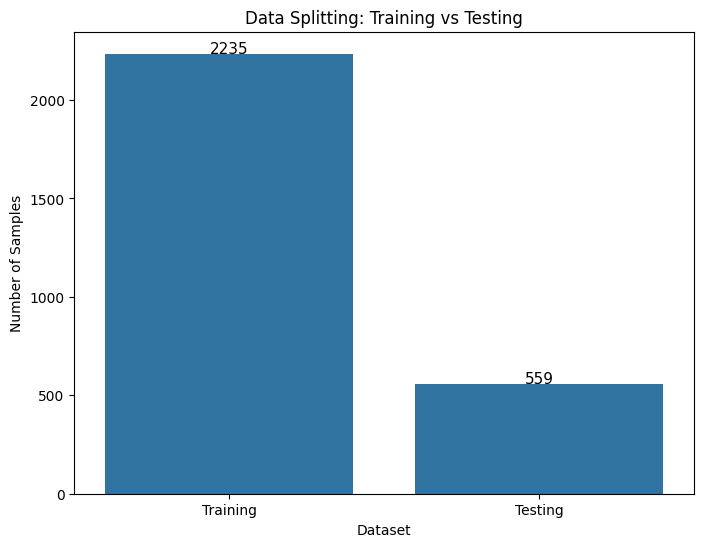

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah data
split_counts = {
    "Training": len(X_train),
    "Testing": len(X_test)
}

# Buat visualisasi
plt.figure(figsize=(8,6))
sns.barplot(
    x=list(split_counts.keys()),
    y=list(split_counts.values())
)

plt.title("Data Splitting: Training vs Testing")
plt.ylabel("Number of Samples")
plt.xlabel("Dataset")

for i, v in enumerate(split_counts.values()):
    plt.text(i, v + 1, str(v), ha='center', fontsize=11)

plt.show()

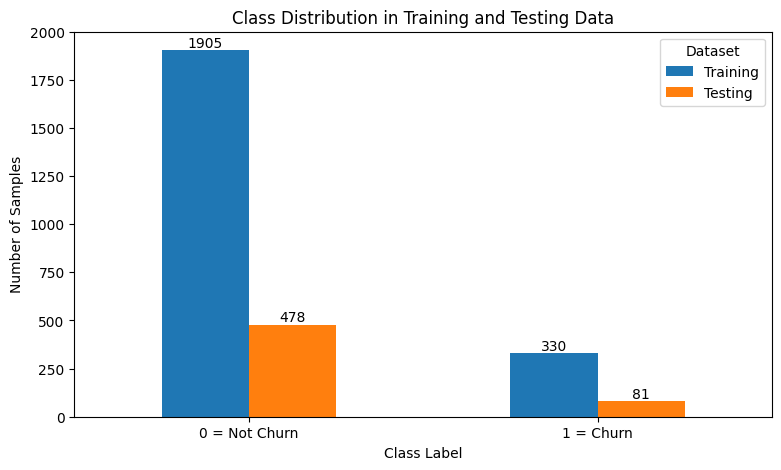

In [59]:
# Buat tabel distribusi kelas
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

class_dist = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts
})

# Ubah label index jadi lebih jelas
class_labels = {
    0: "0 = Not Churn",
    1: "1 = Churn"
}

class_dist.index = [class_labels[i] for i in class_dist.index]

# Plot
ax = class_dist.plot(kind="bar", figsize=(9,5))

plt.title("Class Distribution in Training and Testing Data")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Dataset")

# Tambahkan angka di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

In [60]:
# Cek Data Distribusi Training dan Test
print("Distribusi kelas pada training data:")
print(y_train.value_counts())

print("\nDistribusi kelas pada testing data:")
print(y_test.value_counts())

Distribusi kelas pada training data:
churn
0    1905
1     330
Name: count, dtype: int64

Distribusi kelas pada testing data:
churn
0    478
1     81
Name: count, dtype: int64


6. Modeling dengan KNN

In [63]:
# Training model KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [67]:
# Prediksi Data Testing
y_pred = knn.predict(X_test)

print("Contoh hasil prediksi:")
print(y_pred[:20])

Contoh hasil prediksi:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [71]:
# Compare Data test ke data asli
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(20)

,Actual,Predicted
1299,0,0
3310,0,0
565,0,0
3627,0,0
552,0,0
1816,0,0
2166,0,0
2596,0,0
1344,0,0
1693,0,0


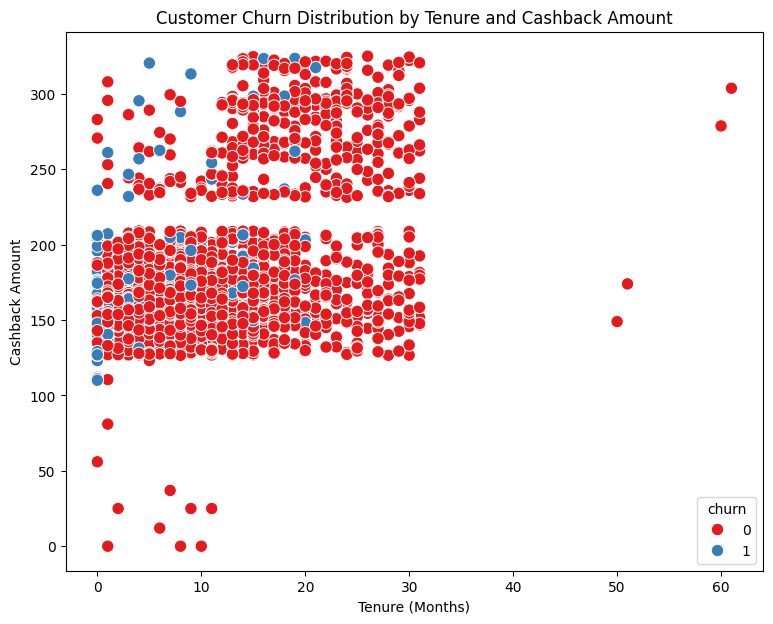

In [78]:
# Visualisasi
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,7))

sns.scatterplot(
    data=df_clean,
    x="tenure",
    y="cashbackamount",
    hue="churn",
    palette="Set1",
    s=80
)

plt.title("Customer Churn Distribution by Tenure and Cashback Amount")
plt.xlabel("Tenure (Months)")
plt.ylabel("Cashback Amount")

plt.show()

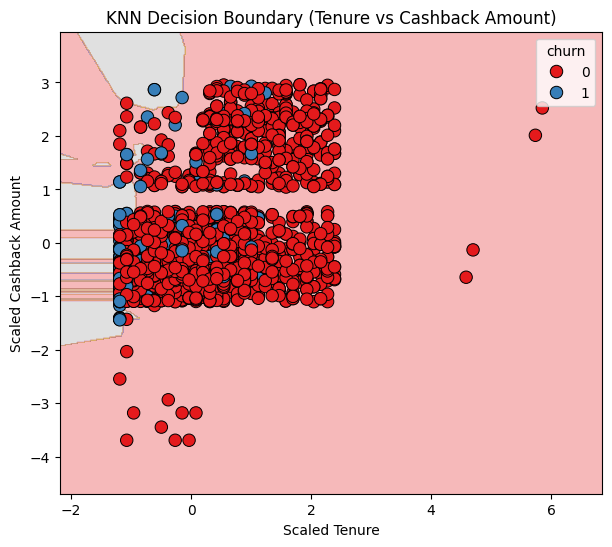

In [81]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Pilih fitur untuk visualisasi

X_vis = df_clean[["tenure","cashbackamount"]]
y_vis = df_clean["churn"]

# Scaling

scaler = StandardScaler()
X_vis_scaled = scaler.fit_transform(X_vis)

# Train KNN

knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_vis_scaled, y_vis)


# Membuat grid untuk decision boundary

x_min, x_max = X_vis_scaled[:,0].min()-1, X_vis_scaled[:,0].max()+1
y_min, y_max = X_vis_scaled[:,1].min()-1, X_vis_scaled[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


# Visualisasi

plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="Set1")

sns.scatterplot(
    x=X_vis_scaled[:,0],
    y=X_vis_scaled[:,1],
    hue=y_vis,
    palette="Set1",
    s=80,
    edgecolor="black"
)

plt.title("KNN Decision Boundary (Tenure vs Cashback Amount)")
plt.xlabel("Scaled Tenure")
plt.ylabel("Scaled Cashback Amount")

plt.show()

In [82]:
from sklearn.metrics import accuracy_score

y_pred = knn.predict(X_test)

print("Jumlah data test :", len(y_test))
print("Akurasi          :", accuracy_score(y_test, y_pred))
print("Jumlah benar     :", (y_test == y_pred).sum())
print("Jumlah salah     :", (y_test != y_pred).sum())
print("Index salah      :", (y_test != y_pred))

Jumlah data test : 559
Akurasi          : 0.8908765652951699
Jumlah benar     : 498
Jumlah salah     : 61
Index salah      : 1299    False
3310    False
565     False
3627    False
552     False
1816    False
2166    False
2596    False
1344    False
1693    False
1016    False
1012    False
1309    False
1489     True
2852    False
1604    False
2342    False
3579     True
1052     True
2272    False
3033    False
2696    False
3452    False
3169    False
3084    False
2564    False
2513    False
2793    False
3791    False
3719     True
2116    False
2044    False
3342    False
3366    False
3106     True
1850    False
2045    False
459     False
538     False
2136    False
3731    False
1846    False
1504    False
3679     True
514     False
2234    False
1797    False
1822    False
1799    False
641     False
1607    False
1867    False
3726    False
1142    False
3675    False
3637    False
2310    False
3600    False
245     False
3390    False
1339    False
2715    False
225    

In [83]:
# Data yang salah diprediksi
import pandas as pd

# 1. Buat kondisi (mask) di mana nilai aktual tidak sama dengan prediksi
salah_prediksi_mask = y_test != y_pred

# 2. Ambil data asli dari df_clean berdasarkan indeks data yang salah
# (Indeks dari y_test tetap sama dengan indeks di df_clean saat di-split)
data_salah = df_clean.loc[y_test[salah_prediksi_mask].index].copy()

# 3. Tambahkan kolom Aktual dan Prediksi agar mudah dibaca (ubah kembali ke bentuk teks)
data_salah['Label_Aktual'] = encoder.inverse_transform(y_test[salah_prediksi_mask])
data_salah['Label_Prediksi'] = encoder.inverse_transform(y_pred[salah_prediksi_mask])

# 4. Tampilkan data yang salah prediksi
print(f"Total data salah prediksi: {len(data_salah)} baris\n")
display(data_salah)

Total data salah prediksi: 61 baris



,tenure,warehousetohome,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,daysincelastorder,cashbackamount,churn,Label_Aktual,Label_Prediksi
1489,15.0,8.0,5,5,1,1,2,0,9.0,298.45,1,1,0
3579,3.0,30.0,4,4,5,2,2,0,4.0,164.04,1,1,0
1052,3.0,22.0,6,4,1,1,2,1,4.0,146.68,0,0,1
3719,14.0,7.0,4,2,3,2,5,1,1.0,172.28,1,1,0
3106,1.0,7.0,5,4,4,2,3,1,3.0,145.70,0,0,1
3679,1.0,16.0,4,4,3,0,3,0,3.0,152.42,1,1,0
3105,1.0,20.0,4,2,4,2,7,0,1.0,182.65,1,1,0
1565,3.0,10.0,4,4,5,2,3,1,6.0,172.23,0,0,1
1096,1.0,14.0,6,2,3,2,3,1,7.0,185.74,1,1,0
716,8.0,10.0,4,4,5,0,6,0,3.0,148.62,1,1,0


7. Model Evaluation

In [84]:
# Akurasi model
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Model KNN :", round(accuracy,4))

Accuracy Model KNN : 0.8909


In [87]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=['Not Churn', 'Churn']))

              precision    recall  f1-score   support

   Not Churn       0.90      0.99      0.94       478
       Churn       0.81      0.32      0.46        81

    accuracy                           0.89       559
   macro avg       0.85      0.65      0.70       559
weighted avg       0.88      0.89      0.87       559



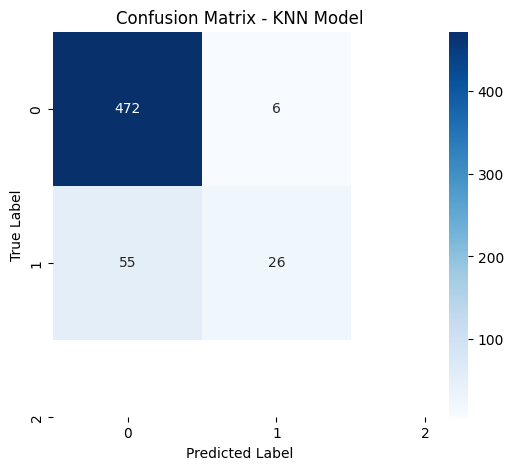

In [88]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

# hitung confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - KNN Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

8. Hyperparameter Optimization

In [89]:
# Metode Elbow
from sklearn.neighbors import KNeighborsClassifier

error_rate = []

k_range = range(1, 21)

for k in k_range:

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    pred_k = knn.predict(X_test)

    error = np.mean(pred_k != y_test)

    error_rate.append(error)

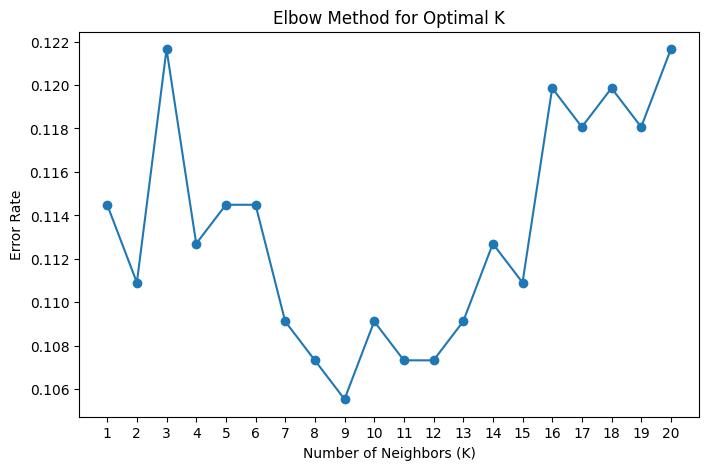

In [90]:
# Visualisasi
plt.figure(figsize=(8,5))

plt.plot(k_range, error_rate, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate")

plt.xticks(k_range)

plt.show()

In [91]:
# Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = {

    "n_neighbors": list(range(1,21)),

    "weights": ["uniform","distance"],

    "metric": ["euclidean","manhattan","minkowski"]
}

grid = GridSearchCV(

    KNeighborsClassifier(),

    param_grid,

    cv=5,

    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best Accuracy: 0.9064876957494408


In [92]:
# MODEL FROM GRID SEARCH

knn_grid = grid.best_estimator_

pred_grid = knn_grid.predict(X_test)

acc_grid = accuracy_score(y_test, pred_grid)

print("Accuracy (Grid Search):", round(acc_grid,4))

Accuracy (Grid Search): 0.9016


In [93]:
# Optuna
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.4 MB/s eta 0:00:00


In [94]:
import optuna

def objective(trial):

    n_neighbors = trial.suggest_int("n_neighbors",1,20)

    weights = trial.suggest_categorical("weights",["uniform","distance"])

    metric = trial.suggest_categorical("metric",["euclidean","manhattan"])


    model = KNeighborsClassifier(

        n_neighbors=n_neighbors,

        weights=weights,

        metric=metric
    )

    model.fit(X_train,y_train)

    preds = model.predict(X_test)

    return accuracy_score(y_test,preds)


study = optuna.create_study(direction="maximize")

study.optimize(objective,n_trials=50)

print("Best Parameters:", study.best_params)

[I 2026-04-24 01:45:48,019] A new study created in memory with name: no-name-49cdb752-f0b9-4605-84eb-e86554bad0db
[I 2026-04-24 01:45:48,202] Trial 0 finished with value: 0.8944543828264758 and parameters: {'n_neighbors': 18, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 0 with value: 0.8944543828264758.
[I 2026-04-24 01:45:48,376] Trial 1 finished with value: 0.8872987477638641 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 0.8944543828264758.
[I 2026-04-24 01:45:48,500] Trial 2 finished with value: 0.8980322003577818 and parameters: {'n_neighbors': 17, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 2 with value: 0.8980322003577818.
[I 2026-04-24 01:45:48,617] Trial 3 finished with value: 0.8872987477638641 and parameters: {'n_neighbors': 20, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 2 with value: 0.8980322003577818.
[I 2026-04-24 01:45:48,766] Trial 4 finished with value: 0.

Best Parameters: {'n_neighbors': 2, 'weights': 'distance', 'metric': 'manhattan'}


In [95]:
best_params = study.best_params

knn_optuna = KNeighborsClassifier(
    n_neighbors=best_params["n_neighbors"],
    weights=best_params["weights"],
    metric=best_params["metric"]
)

knn_optuna.fit(X_train, y_train)

pred_optuna = knn_optuna.predict(X_test)

acc_optuna = accuracy_score(y_test, pred_optuna)

print("Accuracy (Optuna):", round(acc_optuna,4))

Accuracy (Optuna): 0.9034


In [97]:
# Bandingkan seluruh model
acc_elbow = 1 - min(error_rate)
results = pd.DataFrame({

    "Method": ["Elbow Method","Grid Search","Optuna"],

    "Accuracy": [acc_elbow, acc_grid, acc_optuna]
})

print(results)

         Method  Accuracy
0  Elbow Method  0.894454
1   Grid Search  0.901610
2        Optuna  0.903399


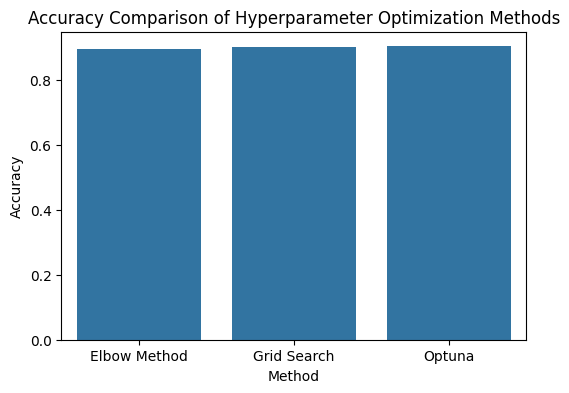

In [98]:
# Visualisasi perbandingan model

plt.figure(figsize=(6,4))

sns.barplot(
    x="Method",
    y="Accuracy",
    data=results
)

plt.title("Accuracy Comparison of Hyperparameter Optimization Methods")

plt.ylabel("Accuracy")

plt.show()

9. Final Model Evaluation

In [99]:
# Hyperparameter Terbaik
best_params = study.best_params

print("Best Hyperparameters (Optuna):")
print(best_params)

Best Hyperparameters (Optuna):
{'n_neighbors': 2, 'weights': 'distance', 'metric': 'manhattan'}


In [100]:
# Prediksi Model Final
final_knn = KNeighborsClassifier(
    n_neighbors=best_params["n_neighbors"],
    weights=best_params["weights"],
    metric=best_params["metric"]
)

# training model final
final_knn.fit(X_train, y_train)

# prediksi data test
y_pred_final = final_knn.predict(X_test)

print("Contoh Prediksi:")
print(y_pred_final[:10])

Contoh Prediksi:
[0 0 1 0 0 0 0 0 0 0]


In [101]:
# Akurasi
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(y_test, y_pred_final)

print("Final Model Accuracy:", round(final_accuracy,4))

Final Model Accuracy: 0.9034


In [103]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_final,
    target_names=['Not Churn', 'Churn']
))

              precision    recall  f1-score   support

   Not Churn       0.94      0.95      0.94       478
       Churn       0.67      0.65      0.66        81

    accuracy                           0.90       559
   macro avg       0.81      0.80      0.80       559
weighted avg       0.90      0.90      0.90       559



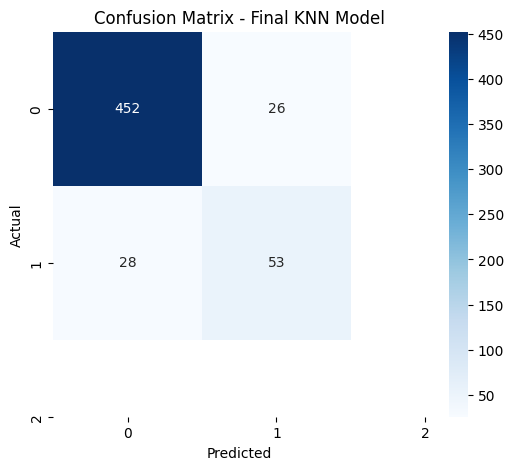

In [107]:
# Visualisasi Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title("Confusion Matrix - Final KNN Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

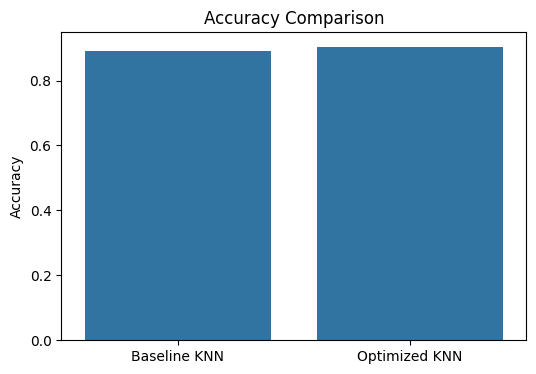

In [109]:
# Visualisasi Perbandingan Model
models = ["Baseline KNN","Optimized KNN"]
scores = [accuracy, final_accuracy]

plt.figure(figsize=(6,4))

sns.barplot(x=models, y=scores)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()